In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
import plotly as px
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('creditcard.csv')

In [4]:
print("Shape of dataset is:",df.shape)

Shape of dataset is: (284807, 31)


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
print(df.describe())


                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [10]:
print(f"\n Fraud Percentage:{df['Class'].mean()*100:.4f}%")


 Fraud Percentage:0.1727%


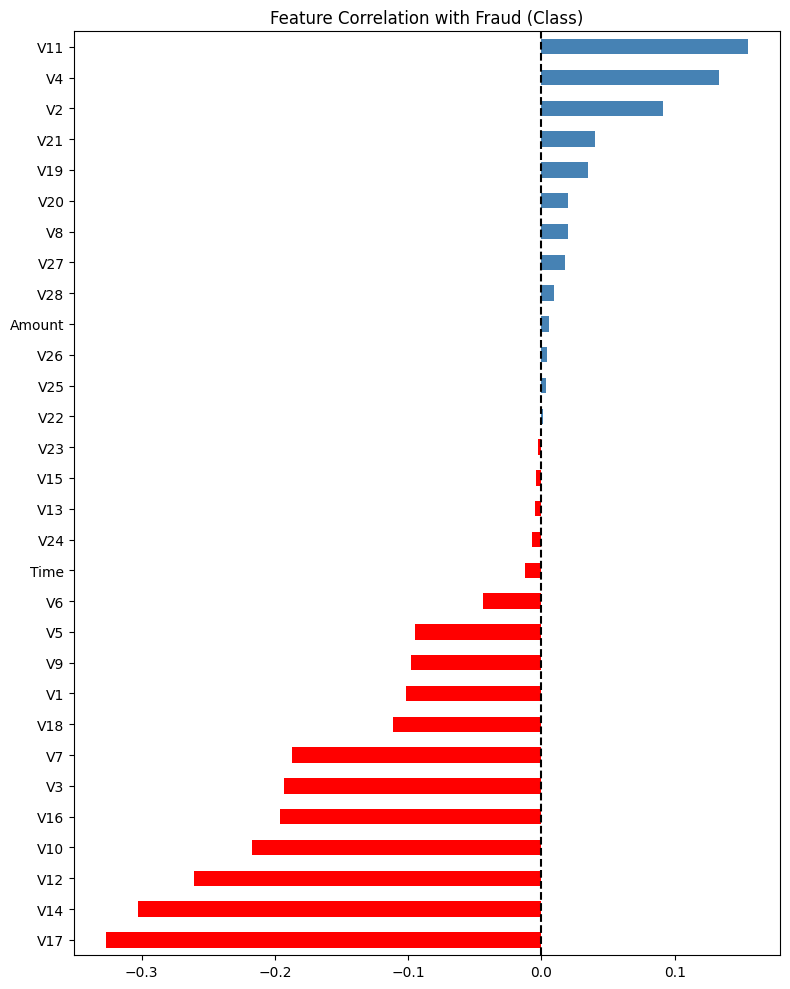

In [11]:
plt.figure(figsize=(8,6))
# Only show correlation of features with Class
corr = df.corr()['Class'].drop('Class').sort_values()
corr.plot(kind='barh', figsize=(8,10), color=['red' if x < 0 else 'steelblue' for x in corr])
plt.title('Feature Correlation with Fraud (Class)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# 
Feature Engineering

In [12]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df['scaled_time']=scaler.fit_transform(df['Time'].values.reshape(-1,1))
df['scaled_amount']=scaler.fit_transform(df['Amount'].values.reshape(-1,1))
# df.drop(['Amount','Time'],axis=1,inplace=True)
print("Scaled...")

Scaled...


In [13]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,scaled_time,scaled_amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,-1.996583,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-1.996583,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,-1.996562,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,-1.996562,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-1.996541,-0.073403


In [14]:
## Dependant and Independant Features
x=df.drop(['Class', 'Time','Amount'], axis=1)
y=df['Class']

print("X Shape:",x.shape)
print("Y Shape:",y.shape)

X Shape: (284807, 30)
Y Shape: (284807,)


In [15]:
print("Features:",x.columns.tolist())

Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'scaled_time', 'scaled_amount']


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
## Train-Test Split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [18]:
print("X_train Shape:",x_train.shape)
print("X_test Shape:",x_test.shape)
print("Y_train Shape:",y_train.shape)
print("Y_test Shape:",y_test.shape)

X_train Shape: (227845, 30)
X_test Shape: (56962, 30)
Y_train Shape: (227845,)
Y_test Shape: (56962,)


#### Applying SMOTE for handling imbalanced dataset

In [19]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_sm,y_train_sm=smote.fit_resample(x_train,y_train)

In [20]:
print("\n Before SMOTE:")
print(f" Normal:{(y_train==0).sum()},Fraud:{(y_train==1).sum()}")
print("\n After SMOTE:")
print(f" Normal:{(y_train_sm==0).sum()},Fraud:{(y_train_sm==1).sum()}")


 Before SMOTE:
 Normal:227451,Fraud:394

 After SMOTE:
 Normal:227451,Fraud:227451


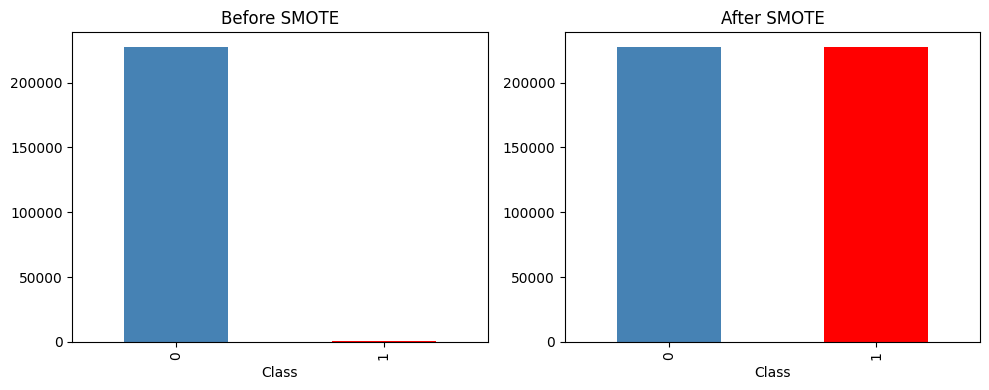

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','red'])
axes[0].set_title('Before SMOTE')
pd.Series(y_train_sm).value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','red'])
axes[1].set_title('After SMOTE')
plt.tight_layout()
plt.show()

#### BaseLine Model+XGBoost

In [22]:

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,average_precision_score,RocCurveDisplay,PrecisionRecallDisplay

In [23]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [24]:
print("Training Logistic Regression Baseline..")
logistic=LogisticRegression(max_iter=1000)
logistic.fit(x_train_sm,y_train_sm)

y_pred_logistic=logistic.predict(x_test)
y_prob_logistic=logistic.predict_proba(x_test)[:,1]

print("\n=== Logistic Regression (Baseline) ===")
print(classification_report(y_test,y_pred_logistic,target_names=['Normal','Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test,y_prob_logistic):.4f}")
print(f"PR_AUC: {average_precision_score(y_test,y_prob_logistic):.4f}")

Training Logistic Regression Baseline..

=== Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC-ROC: 0.9698
PR_AUC: 0.7249


In [25]:
fraud_count=y_train.sum()
normal_count=len(y_train)-fraud_count
scale=normal_count/fraud_count
print("Scale:",np.round(scale,4))

Scale: 577.2868


In [26]:
xgb=XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='aucpr',
    random_state=42)
xgb.fit(x_train_sm,y_train_sm,eval_set=[(x_test,y_test)],verbose=False)
y_pred_xgb=xgb.predict(x_test)
y_prob_xgb=xgb.predict_proba(x_test)[:,1]

print("\n=== XGBoost Classifier===")
print(classification_report(y_test,y_pred_xgb,target_names=['Normal','Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test,y_prob_xgb):.4f}")
print(f"PR_AUC: {average_precision_score(y_test,y_prob_xgb):.4f}")


=== XGBoost Classifier===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.52      0.88      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9792
PR_AUC: 0.8715


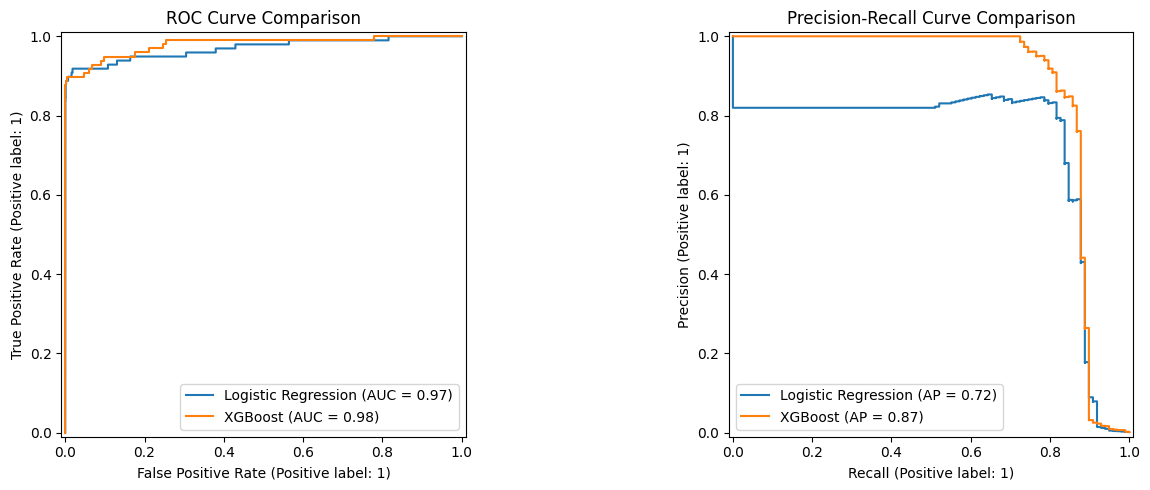

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_logistic, name="Logistic Regression", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost", ax=axes[0])
axes[0].set_title('ROC Curve Comparison')

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob_logistic, name="Logistic Regression", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost", ax=axes[1])
axes[1].set_title('Precision-Recall Curve Comparison')

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

## Hyperparameter Tuning

In [28]:
from sklearn.model_selection import RandomizedSearchCV
xgb_params={
    "n_estimators":[100,200,300,400],
    "max_depth":[3,4,5,6,7],
    "learning_rate":[0.01,0.05,0.1,0.2],
    "subsample":[0.6,0.7,0.8,0.9],
    "colsample_bytree":[0.6,0.7,0.8,0.9],
    "scale_pos_weight":[scale]
}
randomsearch=RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42,eval_metric='aucpr'),
    param_distributions=xgb_params,
    n_iter=30,
    scoring='average_precision',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42)
randomsearch.fit(x_train_sm,y_train_sm)
print("\n Best Params:",randomsearch.best_params_)
print("\n Best PR-AUC:",randomsearch.best_score_)
      

Fitting 3 folds for each of 30 candidates, totalling 90 fits

 Best Params: {'subsample': 0.9, 'scale_pos_weight': np.float64(577.2868020304569), 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.6}

 Best PR-AUC: 0.9999891863102994


In [29]:
# Train Fine-Tuned Model

In [30]:
best_xgb=randomsearch.best_estimator_
y_pred_best=best_xgb.predict(x_test)
y_prob_best=best_xgb.predict_proba(x_test)[:,1]

print("\n=== Fine-Tuned XGBoost Classifier===")
print(classification_report(y_test,y_pred_best,target_names=['Normal','Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test,y_prob_best):.4f}")
print(f"PR_AUC: {average_precision_score(y_test,y_prob_best):.4f}")


=== Fine-Tuned XGBoost Classifier===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.58      0.89      0.70        98

    accuracy                           1.00     56962
   macro avg       0.79      0.94      0.85     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9801
PR_AUC: 0.8795


In [31]:
# SHAP Explainabilty

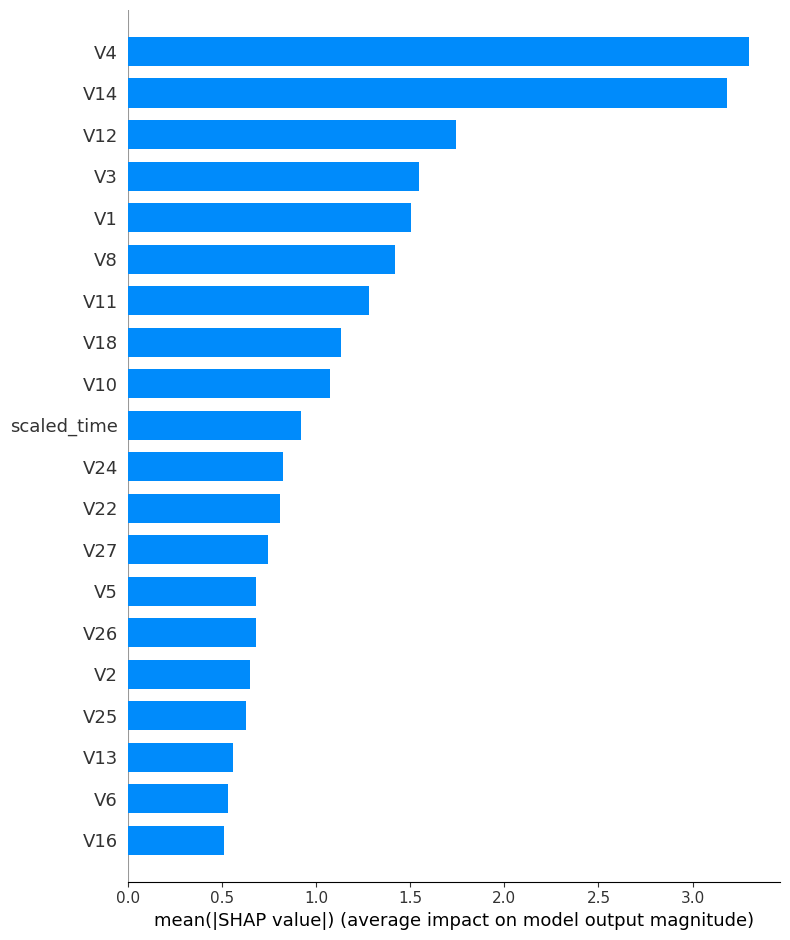

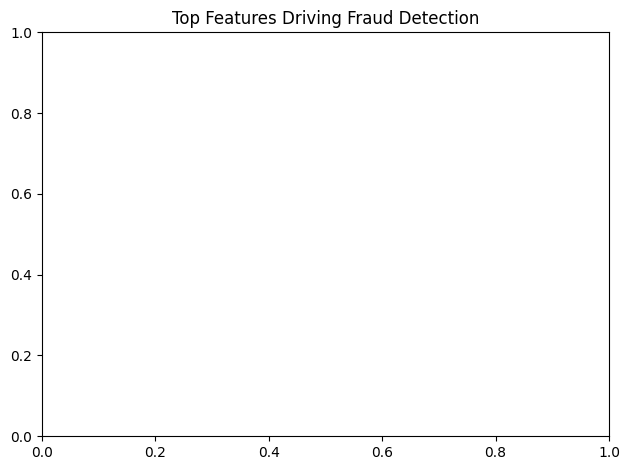

In [32]:
import shap
explainer=shap.TreeExplainer(best_xgb)
shap_values=explainer.shap_values(x_test[:500])

#which values matter most overall??
plt.figure()
shap.summary_plot(shap_values,x_test[:500],plot_type="bar",show="false")
plt.title("Top Features Driving Fraud Detection")
plt.tight_layout()
plt.savefig("shap_summary.png")
plt.show()

In [33]:
## Single Transaction Explanation

In [34]:
# Find how many rows we need to include at least one fraud
print("Fraud positions in X_test:")
fraud_positions = [i for i, idx in enumerate(x_test.index) if y_test[idx] == 1]
print(f"First fraud found at position: {fraud_positions[0]}")
print(f"So we need at least {fraud_positions[0]+1} rows in our sample")

Fraud positions in X_test:
First fraud found at position: 840
So we need at least 841 rows in our sample


Transaction index: 77348
Actual label: FRAUD ✅
Model probability: 1.0000


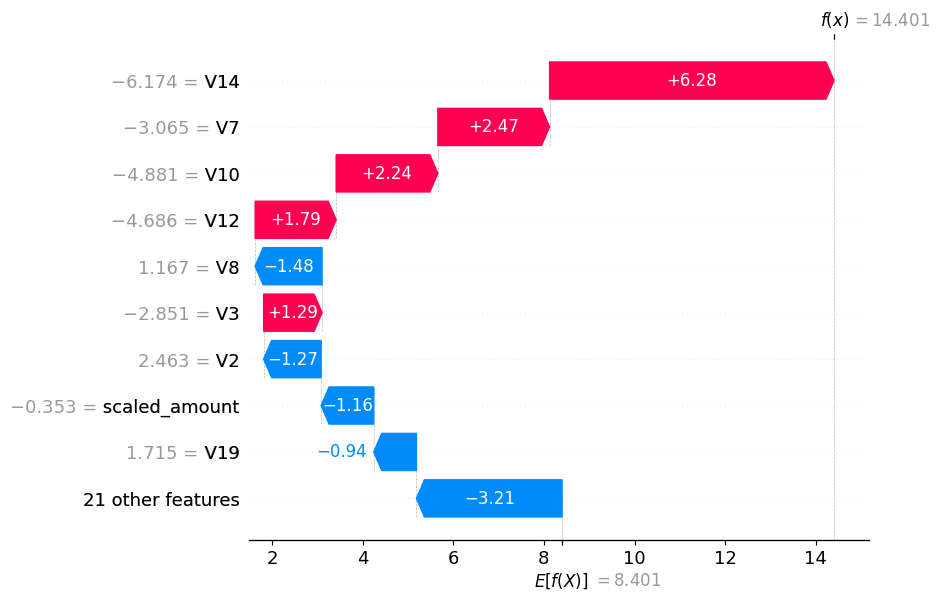

In [35]:
sample_size = 841  # we know exactly where first fraud is

x_test_sample = x_test.iloc[:sample_size]
y_test_sample = y_test.iloc[:sample_size]

# Recompute SHAP on correct sample
shap_values = explainer.shap_values(x_test_sample)

# fraud is at position 840
fraud_pos = 840
fraud_idx = x_test.index[fraud_pos]

print(f"Transaction index: {fraud_idx}")
print(f"Actual label: FRAUD ✅")
print(f"Model probability: {y_prob_best[fraud_pos]:.4f}")

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[fraud_pos],
        base_values   = explainer.expected_value,
        data          = x_test_sample.iloc[fraud_pos],
        feature_names = x_test.columns.tolist()
    )
)

In [36]:
import mlflow
import mlflow.xgboost
mlflow.set_experiment("fraud-detection")
with mlflow.start_run(run_name="XGBoost_Tuned_Final"):
    mlflow.log_params(randomsearch.best_params_)
    mlflow.log_metric("auc-roc",roc_auc_score(y_test,y_prob_best))
    mlflow.log_metric("pr-auc",average_precision_score(y_test,y_prob_best))
    # mlflow.log_artifact("eda_plots.png")
    mlflow.log_artifact('model_comparison.png')
    mlflow.log_artifact("shap_summary.png")
    mlflow.xgboost.log_model(best_xgb,"xgboost_fraud_model")
    print("Logged to MLflow")
print("\nRun: mlflow ui in terminal to see dashboard")

2026/06/01 23:02:02 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/01 23:02:02 INFO mlflow.store.db.utils: Updating database tables
2026/06/01 23:02:04 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection' does not exist. Creating a new experiment.
2026/06/01 23:02:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged to MLflow

Run: mlflow ui in terminal to see dashboard


In [37]:
import joblib
joblib.dump(best_xgb,'../models/fraud_model.pkl')
joblib.dump(scaler,'../models/scaler.pkl')
print("Model saved..")
print("Scaler saved..")

Model saved..
Scaler saved..


In [38]:
print("Model expects these features:")
print(f"Number of features: {best_xgb.n_features_in_}")
print(f"\nFeature names: {best_xgb.get_booster().feature_names}")

Model expects these features:
Number of features: 30

Feature names: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'scaled_time', 'scaled_amount']


In [39]:
df_original = pd.read_csv('creditcard.csv')
fraud_row = df_original[df_original['Class'] == 1].iloc[0]

print(f"Time:   {fraud_row['Time']}")
print(f"Amount: {fraud_row['Amount']}")

v_features = [round(fraud_row[f'V{i}'], 6) for i in range(1, 29)]
print(f"\nV Features:\n{v_features}")

Time:   406.0
Amount: 0.0

V Features:
[np.float64(-2.312227), np.float64(1.951992), np.float64(-1.609851), np.float64(3.997906), np.float64(-0.522188), np.float64(-1.426545), np.float64(-2.537387), np.float64(1.391657), np.float64(-2.770089), np.float64(-2.772272), np.float64(3.202033), np.float64(-2.899907), np.float64(-0.595222), np.float64(-4.289254), np.float64(0.389724), np.float64(-1.140747), np.float64(-2.830056), np.float64(-0.016822), np.float64(0.416956), np.float64(0.126911), np.float64(0.517232), np.float64(-0.035049), np.float64(-0.465211), np.float64(0.320198), np.float64(0.044519), np.float64(0.17784), np.float64(0.261145), np.float64(-0.143276)]


In [40]:
df_original = pd.read_csv('creditcard.csv')
fraud_row = df_original[df_original['Class'] == 0].iloc[0]

print(f"Time:   {fraud_row['Time']}")
print(f"Amount: {fraud_row['Amount']}")

v_features = [round(fraud_row[f'V{i}'], 6) for i in range(1, 29)]
print(f"\nV Features:\n{v_features}")

Time:   0.0
Amount: 149.62

V Features:
[np.float64(-1.359807), np.float64(-0.072781), np.float64(2.536347), np.float64(1.378155), np.float64(-0.338321), np.float64(0.462388), np.float64(0.239599), np.float64(0.098698), np.float64(0.363787), np.float64(0.090794), np.float64(-0.5516), np.float64(-0.617801), np.float64(-0.99139), np.float64(-0.311169), np.float64(1.468177), np.float64(-0.470401), np.float64(0.207971), np.float64(0.025791), np.float64(0.403993), np.float64(0.251412), np.float64(-0.018307), np.float64(0.277838), np.float64(-0.110474), np.float64(0.066928), np.float64(0.128539), np.float64(-0.189115), np.float64(0.133558), np.float64(-0.021053)]


In [41]:
# Get fraud transactions with different probability levels
fraud_rows = df[df['Class'] == 1].head(40)

print("Fraud transactions with their model probabilities:\n")
for idx, row in fraud_rows.iterrows():
    v_features = [row[f'V{i}'] for i in range(1, 29)]
    
    # Scale amount and time
    scaled_amount = row['scaled_amount']
    scaled_time  = row['scaled_time']
    
    features = np.array(v_features + [scaled_amount, scaled_time]).reshape(1, -1)
    prob = best_xgb.predict_proba(features)[0][1]
    
    print(f"Index: {idx} | Amount: {row['scaled_amount']} | Probability: {prob*100:.2f}%")

Fraud transactions with their model probabilities:

Index: 541 | Amount: -0.35322939296682354 | Probability: 100.00%
Index: 623 | Amount: 1.7617582036263544 | Probability: 0.00%
Index: 4920 | Amount: 0.60603142754471 | Probability: 99.97%
Index: 6108 | Amount: -0.11734230752448421 | Probability: 100.00%
Index: 6329 | Amount: -0.3492313067728856 | Probability: 100.00%
Index: 6331 | Amount: -0.3492313067728856 | Probability: 100.00%
Index: 6334 | Amount: -0.3492313067728856 | Probability: 100.00%
Index: 6336 | Amount: -0.3492313067728856 | Probability: 100.00%
Index: 6338 | Amount: -0.3492313067728856 | Probability: 100.00%
Index: 6427 | Amount: -0.3492313067728856 | Probability: 100.00%
Index: 6446 | Amount: -0.3492313067728856 | Probability: 100.00%
Index: 6472 | Amount: -0.3492313067728856 | Probability: 100.00%
Index: 6529 | Amount: -0.3492313067728856 | Probability: 100.00%
Index: 6609 | Amount: -0.3492313067728856 | Probability: 100.00%
Index: 6641 | Amount: -0.3492313067728856 | P

In [42]:
# Save original fraud transactions BEFORE scaling
df_original = pd.read_csv('creditcard.csv')

results = []
for idx, row in df_original[df_original['Class']==1].iterrows():
    v_features = [row[f'V{i}'] for i in range(1, 29)]
    
    # Scale for model
    scaled_amount = scaler.transform([[row['Amount']]])[0][0]
    scaled_time   = scaler.transform([[row['Time']]])[0][0]
    
    features = np.array(v_features + [scaled_amount, scaled_time]).reshape(1, -1)
    prob = best_xgb.predict_proba(features)[0][1]
    
    results.append({
        'idx'   : idx,
        'amount': row['Amount'],  # ← original dollar amount
        'time'  : row['Time'],    # ← original time
        'prob'  : round(prob*100, 2),
        'v'     : [round(row[f'V{i}'], 6) for i in range(1, 29)]
    })

results_df = pd.DataFrame(results)

# Pick varied probabilities
high   = results_df[results_df['prob'] > 80].iloc[0]
medium = results_df[(results_df['prob'] >= 40) & (results_df['prob'] < 80)]
low    = results_df[(results_df['prob'] >= 10) & (results_df['prob'] < 40)]

print("HIGH:", high['prob'], "% | Amount:", high['amount'])

if len(medium) > 0:
    medium = medium.iloc[0]
    print("MEDIUM:", medium['prob'], "% | Amount:", medium['amount'])
else:
    print("MEDIUM: none found")

if len(low) > 0:
    low = low.iloc[0]
    print("LOW:", low['prob'], "% | Amount:", low['amount'])
else:
    print("LOW: none found")

HIGH: 100.0 % | Amount: 0.0
MEDIUM: 54.1 % | Amount: 3.79
LOW: 20.52 % | Amount: 1809.68


In [43]:
high   = results_df[results_df['prob'] > 80].iloc[0]
medium = results_df[(results_df['prob'] >= 40) & (results_df['prob'] < 80)].iloc[0]
low    = results_df[(results_df['prob'] >= 10) & (results_df['prob'] < 40)].iloc[0]

for label, row in [('HIGH', high), ('MEDIUM', medium), ('LOW', low)]:
    print(f"\n=== {label} RISK ({row['prob']}%) ===")
    print(f"amount: {row['amount']}")
    print(f"time:   {row['time']}")
    print(f"v:      {list(row['v'])}")


=== HIGH RISK (100.0%) ===
amount: 0.0
time:   406.0
v:      [np.float64(-2.312227), np.float64(1.951992), np.float64(-1.609851), np.float64(3.997906), np.float64(-0.522188), np.float64(-1.426545), np.float64(-2.537387), np.float64(1.391657), np.float64(-2.770089), np.float64(-2.772272), np.float64(3.202033), np.float64(-2.899907), np.float64(-0.595222), np.float64(-4.289254), np.float64(0.389724), np.float64(-1.140747), np.float64(-2.830056), np.float64(-0.016822), np.float64(0.416956), np.float64(0.126911), np.float64(0.517232), np.float64(-0.035049), np.float64(-0.465211), np.float64(0.320198), np.float64(0.044519), np.float64(0.17784), np.float64(0.261145), np.float64(-0.143276)]

=== MEDIUM RISK (54.099998474121094%) ===
amount: 3.79
time:   17220.0
v:      [np.float64(1.189784), np.float64(0.942289), np.float64(0.082334), np.float64(3.02405), np.float64(0.412406), np.float64(-0.214415), np.float64(0.053558), np.float64(-0.110353), np.float64(0.883798), np.float64(-0.554224), np.